In [1]:
# CHẠY TẠI CELL 1: KHAI BÁO THƯ VIỆN CỐT LÕI
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from datetime import datetime

# Tối ưu hóa cấu hình hiển thị của biểu đồ và tắt cảnh báo hệ thống
sns.set_theme(style="whitegrid")
warnings.filterwarnings('ignore')
print("=== THƯ VIỆN ĐÃ ĐƯỢC KHỞI TẠO THÀNH CÔNG ===")

=== THƯ VIỆN ĐÃ ĐƯỢC KHỞI TẠO THÀNH CÔNG ===


In [2]:
# CHẠY TẠI CELL 2: TIỀN XỬ LÝ VÀ CHUẨN HÓA DỮ LIỆU GỐC (541,910 DÒNG)
print("=== BẮT ĐẦU QUY TRÌNH TIỀN XỬ LÝ DỮ LIỆU ĐỒ ÁN ===")

# 1. Nạp file dữ liệu thô từ Kaggle
df_raw = pd.read_csv("data.csv", encoding="ISO-8859-1")
print(f"Kích thước tệp thô ban đầu: {df_raw.shape[0]:,} dòng, {df_raw.shape[1]} cột.")

# 2. Loại bỏ các bản ghi bị khuyết định danh khách hàng (CustomerID)
df_clean = df_raw.dropna(subset=['CustomerID']).reset_index(drop=True)
# Ép CustomerID từ kiểu float về chuỗi định danh (string) cho chuẩn kỹ thuật
df_clean['CustomerID'] = df_clean['CustomerID'].astype(int).astype(str)

# 3. Lọc bỏ các bản ghi có đơn giá (UnitPrice) không hợp lệ (nhỏ hơn hoặc bằng 0)
df_clean = df_clean[df_clean['UnitPrice'] > 0].reset_index(drop=True)

# 4. Chuẩn hóa định dạng chuỗi thời gian (Time-series Formatting)
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])

# 5. Kỹ nghệ đặc trưng cơ bản (Feature Engineering)
# Tính tổng giá trị của từng dòng sản phẩm trong hóa đơn
df_clean['TotalAmount'] = df_clean['Quantity'] * df_clean['UnitPrice']

# Nhận diện đơn hàng bị hủy (Các hóa đơn có InvoiceNo bắt đầu bằng chữ 'C' hoặc Quantity âm)
df_clean['IsCancelled'] = df_clean['InvoiceNo'].str.startswith('C', na=False) | (df_clean['Quantity'] < 0)

# Trích xuất các biến thời gian phục vụ các câu hỏi EDA phía sau
df_clean['Year'] = df_clean['InvoiceDate'].dt.year
df_clean['Month'] = df_clean['InvoiceDate'].dt.month
df_clean['Hour'] = df_clean['InvoiceDate'].dt.hour
df_clean['DayOfWeek'] = df_clean['InvoiceDate'].dt.dayofweek # 0: Thứ 2, 6: Chủ Nhật

print("\n--- THÔNG TIN BỘ DỮ LIỆU SAU KHI ĐÃ TIỀN XỬ LÝ SẠCH ---")
print(f"Kích thước tệp dữ liệu sạch: {df_clean.shape[0]:,} dòng.")
print(f"Số lượng khách hàng duy nhất (Unique Customers): {df_clean['CustomerID'].nunique():,}")
print(f"Số lượng đơn hàng bị hủy/hoàn trả phát sinh: {df_clean['IsCancelled'].sum():,} dòng.")

# Hiển thị cấu trúc dữ liệu sạch kiểm tra tổng thể
print("\n--- 3 DÒNG DỮ LIỆU ĐẦU TIÊN SAU TIỀN XỬ LÝ ---")
print(df_clean[['InvoiceNo', 'CustomerID', 'InvoiceDate', 'TotalAmount', 'IsCancelled']].head(3))

=== BẮT ĐẦU QUY TRÌNH TIỀN XỬ LÝ DỮ LIỆU ĐỒ ÁN ===
Kích thước tệp thô ban đầu: 541,909 dòng, 8 cột.

--- THÔNG TIN BỘ DỮ LIỆU SAU KHI ĐÃ TIỀN XỬ LÝ SẠCH ---
Kích thước tệp dữ liệu sạch: 406,789 dòng.
Số lượng khách hàng duy nhất (Unique Customers): 4,371
Số lượng đơn hàng bị hủy/hoàn trả phát sinh: 8,905 dòng.

--- 3 DÒNG DỮ LIỆU ĐẦU TIÊN SAU TIỀN XỬ LÝ ---
  InvoiceNo CustomerID         InvoiceDate  TotalAmount  IsCancelled
0    536365      17850 2010-12-01 08:26:00        15.30        False
1    536365      17850 2010-12-01 08:26:00        20.34        False
2    536365      17850 2010-12-01 08:26:00        22.00        False


--- [CÂU 1] PHÂN TÍCH XU HƯỚNG MUA SẮM THEO GIỜ VÀ NGÀY TRONG TUẦN ---


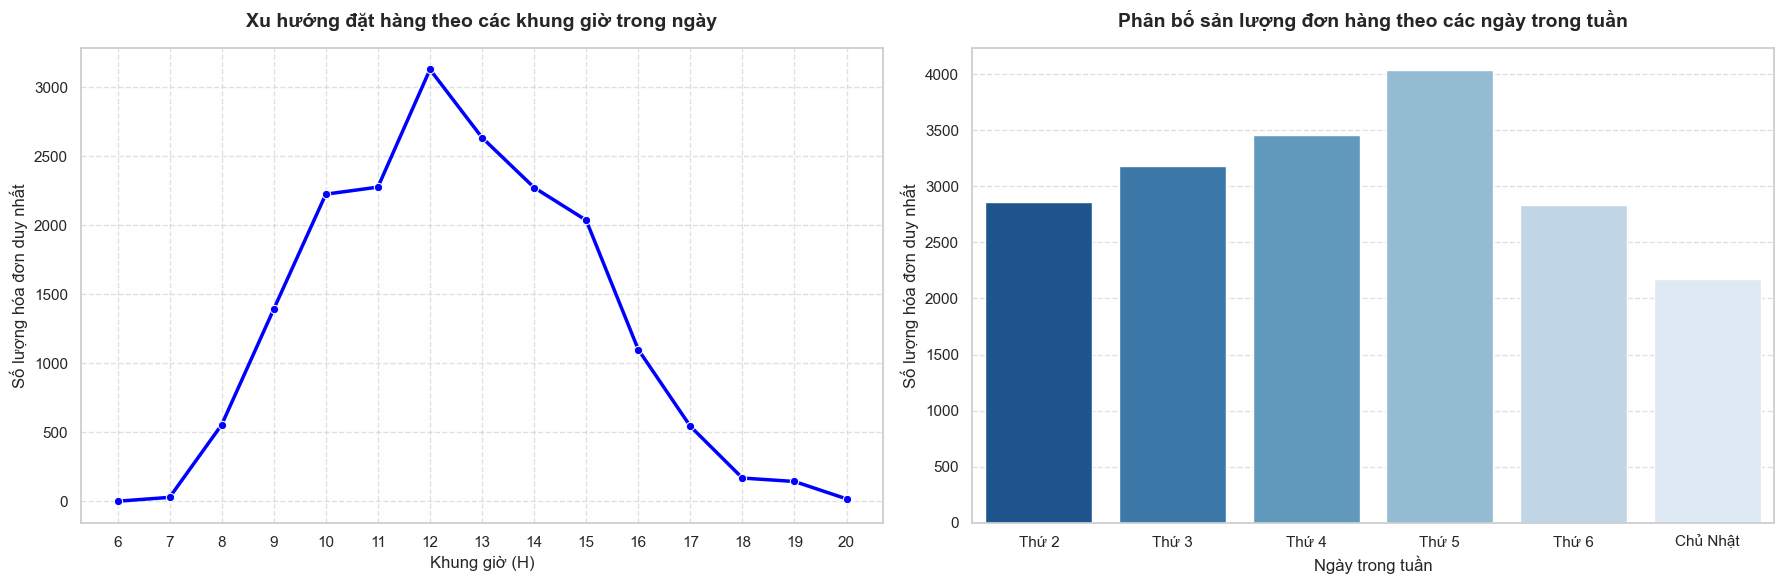


[BẢNG SỐ LIỆU KHUNG GIỜ MUA SẮM PHỔ BIẾN]:
 Giờ  Số lượng đơn hàng
  12               3130
  13               2636
  11               2277
  14               2274
  10               2226
  15               2037
   9               1393
  16               1100
   8                555
  17                544
  18                169
  19                144
   7                 29
  20                 18
   6                  1

[BẢNG SỐ LIỆU NGÀY TRONG TUẦN MUA SẮM PHỔ BIẾN]:
Ngày trong tuần  Số lượng đơn hàng
          Thứ 2               2863
          Thứ 3               3184
          Thứ 4               3455
          Thứ 5               4032
          Thứ 6               2829
       Chủ Nhật               2169


In [3]:
# CHẠY TẠI CELL 3: GIẢI QUYẾT CÂU HỎI EDA 1
print("--- [CÂU 1] PHÂN TÍCH XU HƯỚNG MUA SẮM THEO GIỜ VÀ NGÀY TRONG TUẦN ---")

# Lọc lấy các đơn hàng thành công (không bị hủy) để phân tích hành vi mua thật
df_success = df_clean[df_clean['IsCancelled'] == False]

# 1. Thống kê theo Khung giờ (Hour)
hourly_orders = df_success.groupby('Hour')['InvoiceNo'].nunique().reset_index()
hourly_orders.columns = ['Giờ', 'Số lượng đơn hàng']

# 2. Thống kê theo Ngày trong tuần (DayOfWeek)
day_orders = df_success.groupby('DayOfWeek')['InvoiceNo'].nunique().reset_index()
day_mapping = {0: 'Thứ 2', 1: 'Thứ 3', 2: 'Thứ 4', 3: 'Thứ 5', 4: 'Thứ 6', 5: 'Thứ 7', 6: 'Chủ Nhật'}
day_orders['Ngày trong tuần'] = day_orders['DayOfWeek'].map(day_mapping)
day_orders = day_orders[['Ngày trong tuần', 'InvoiceNo']].rename(columns={'InvoiceNo': 'Số lượng đơn hàng'})

# --- TIẾN HÀNH VẼ BIỂU ĐỒ TRỰC QUAN HÓA GIỜ VÀ NGÀY VÀNG ---
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Biểu đồ 1: Lượng đơn hàng theo khung giờ trong ngày
sns.lineplot(data=hourly_orders, x='Giờ', y='Số lượng đơn hàng', ax=axes[0], color='blue', marker='o', linewidth=2.5)
axes[0].set_title('Xu hướng đặt hàng theo các khung giờ trong ngày', fontsize=14, weight='bold', pad=15)
axes[0].set_xlabel('Khung giờ (H)', fontsize=12)
axes[0].set_ylabel('Số lượng hóa đơn duy nhất', fontsize=12)
axes[0].set_xticks(range(df_success['Hour'].min(), df_success['Hour'].max() + 1))
axes[0].grid(True, linestyle='--', alpha=0.6)

# Biểu đồ 2: Lượng đơn hàng theo các ngày trong tuần
sns.barplot(data=day_orders, x='Ngày trong tuần', y='Số lượng đơn hàng', ax=axes[1], palette='Blues_r')
axes[1].set_title('Phân bố sản lượng đơn hàng theo các ngày trong tuần', fontsize=14, weight='bold', pad=15)
axes[1].set_xlabel('Ngày trong tuần', fontsize=12)
axes[1].set_ylabel('Số lượng hóa đơn duy nhất', fontsize=12)
axes[1].grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

# In bảng số liệu tóm tắt kết quả
print("\n[BẢNG SỐ LIỆU KHUNG GIỜ MUA SẮM PHỔ BIẾN]:")
print(hourly_orders.sort_values(by='Số lượng đơn hàng', ascending=False).to_string(index=False))

print("\n[BẢNG SỐ LIỆU NGÀY TRONG TUẦN MUA SẮM PHỔ BIẾN]:")
print(day_orders.to_string(index=False))

--- [CÂU 2] PHÂN TÍCH TỶ LỆ HỦY ĐƠN / HOÀN TRẢ THEO DANH MỤC SẢN PHẨM ---


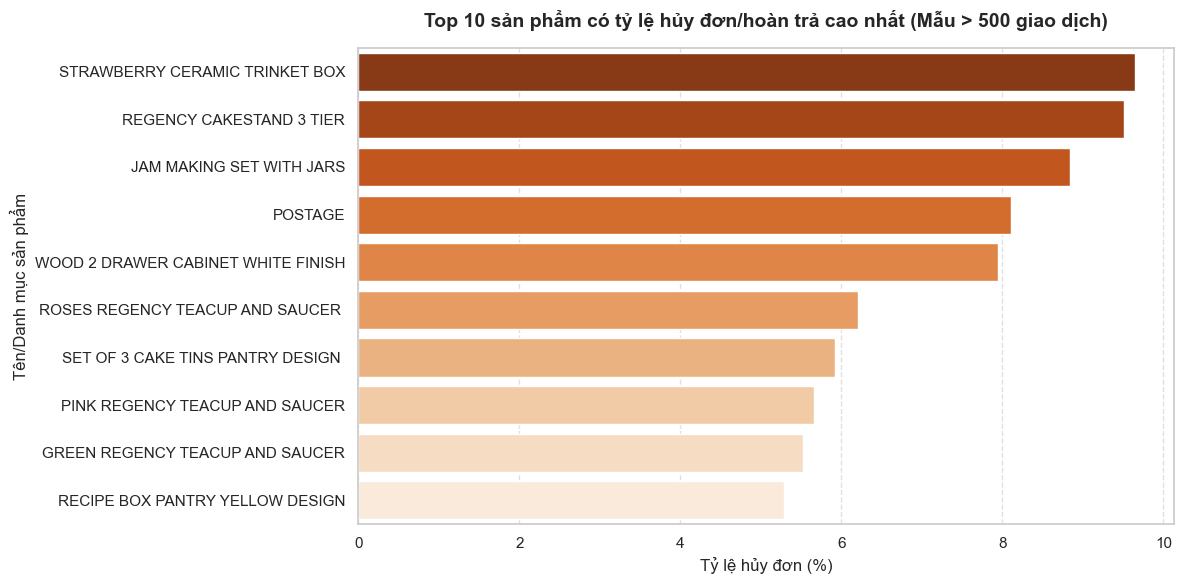


[BẢNG SỐ LIỆU TOP 10 SẢN PHẨM CÓ TỶ LỆ HỦY CAO NHẤT]:
                       Description  Tong_So_Dong  So_Dong_Huy  Ty_Le_Huy_%
    STRAWBERRY CERAMIC TRINKET BOX           570           55     9.649123
          REGENCY CAKESTAND 3 TIER          1904          181     9.506303
          JAM MAKING SET WITH JARS           973           86     8.838643
                           POSTAGE          1196           97     8.110368
WOOD 2 DRAWER CABINET WHITE FINISH           566           45     7.950530
  ROSES REGENCY TEACUP AND SAUCER            854           53     6.206089
 SET OF 3 CAKE TINS PANTRY DESIGN           1232           73     5.925325
    PINK REGENCY TEACUP AND SAUCER           619           35     5.654281
   GREEN REGENCY TEACUP AND SAUCER           761           42     5.519054
   RECIPE BOX PANTRY YELLOW DESIGN           890           47     5.280899


In [4]:
# CHẠY TẠI CELL 4: GIẢI QUYẾT CÂU HỎI EDA 2
print("--- [CÂU 2] PHÂN TÍCH TỶ LỆ HỦY ĐƠN / HOÀN TRẢ THEO DANH MỤC SẢN PHẨM ---")

# 1. Tính tổng số dòng và số dòng bị hủy của từng mặt hàng (Description)
product_stats = df_clean.groupby('Description').agg(
    Tong_So_Dong=('IsCancelled', 'count'),
    So_Dong_Huy=('IsCancelled', 'sum')
).reset_index()

# 2. Tính tỷ lệ phần trăm hủy đơn
product_stats['Ty_Le_Huy_%'] = (product_stats['So_Dong_Huy'] / product_stats['Tong_So_Dong']) * 100

# 3. Lọc bỏ các sản phẩm quá ít giao dịch (chỉ xét sản phẩm xuất hiện > 500 lần để đảm bảo tính thống kê)
top_products = product_stats[product_stats['Tong_So_Dong'] > 500].sort_values(by='Ty_Le_Huy_%', ascending=False)

# --- V VẼ BIỂU ĐỒ TRỰC QUAN HÓA TOP 10 SẢN PHẨM BỊ HỦY NHIỀU NHẤT ---
plt.figure(figsize=(12, 6))
sns.barplot(data=top_products.head(10), x='Ty_Le_Huy_%', y='Description', palette='Oranges_r')
plt.title('Top 10 sản phẩm có tỷ lệ hủy đơn/hoàn trả cao nhất (Mẫu > 500 giao dịch)', fontsize=14, weight='bold', pad=15)
plt.xlabel('Tỷ lệ hủy đơn (%)', fontsize=12)
plt.ylabel('Tên/Danh mục sản phẩm', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# In bảng số liệu chi tiết
print("\n[BẢNG SỐ LIỆU TOP 10 SẢN PHẨM CÓ TỶ LỆ HỦY CAO NHẤT]:")
print(top_products.head(10)[['Description', 'Tong_So_Dong', 'So_Dong_Huy', 'Ty_Le_Huy_%']].to_string(index=False))

--- [CÂU 3] PHÂN TÍCH GIÁ TRỊ ĐƠN HÀNG TRUNG BÌNH THEO MÙA / THÁNG ---


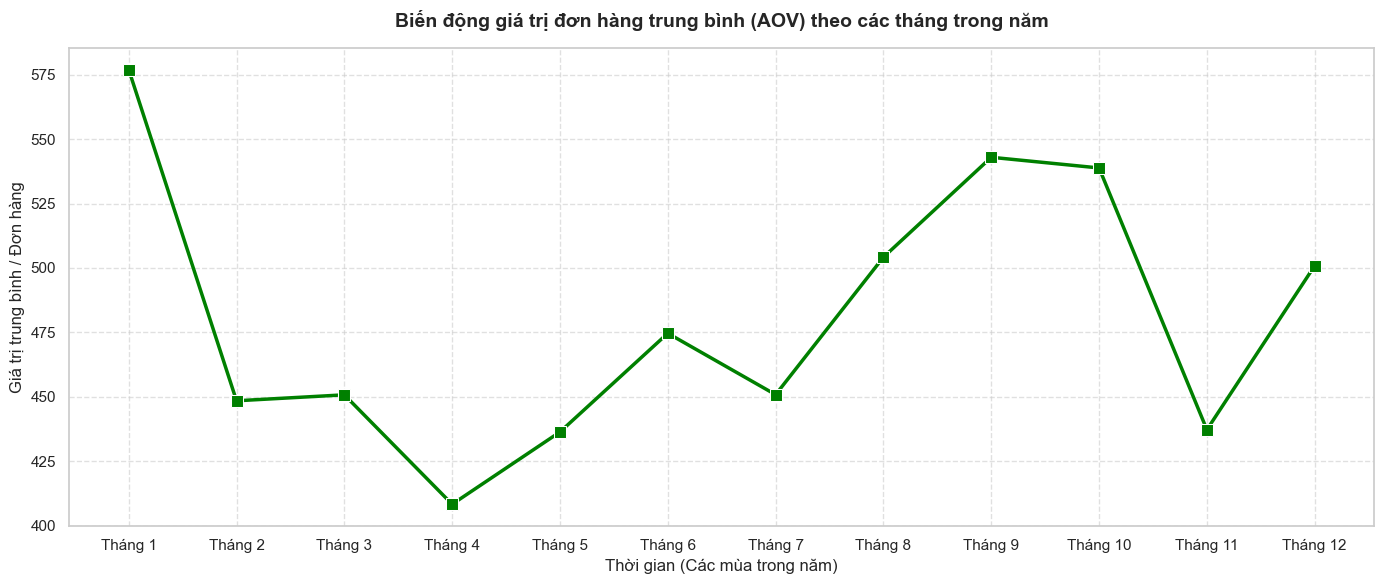

[BẢNG SỐ LIỆU GIÁ TRỊ ĐƠN HÀNG TRUNG BÌNH QUA CÁC THÁNG]:
Tên Tháng  Giá trị đơn hàng trung bình
  Tháng 1                   576.945329
  Tháng 2                   448.482798
  Tháng 3                   450.795428
  Tháng 4                   408.355406
  Tháng 5                   436.395215
  Tháng 6                   474.668837
  Tháng 7                   450.857258
  Tháng 8                   504.174922
  Tháng 9                   542.927853
 Tháng 10                   538.786309
 Tháng 11                   437.266609
 Tháng 12                   500.875427


In [5]:
# CHẠY TẠI CELL 5: GIẢI QUYẾT CÂU HỎI EDA 3
print("--- [CÂU 3] PHÂN TÍCH GIÁ TRỊ ĐƠN HÀNG TRUNG BÌNH THEO MÙA / THÁNG ---")

# 1. Tính tổng giá trị của từng hóa đơn (InvoiceNo) theo từng tháng
invoice_value = df_success.groupby(['Month', 'InvoiceNo'])['TotalAmount'].sum().reset_index()

# 2. Tính giá trị đơn hàng trung bình (AOV - Average Order Value) của mỗi tháng
monthly_aov = invoice_value.groupby('Month')['TotalAmount'].mean().reset_index()
monthly_aov.columns = ['Tháng', 'Giá trị đơn hàng trung bình']

# Mapping tên tháng tiếng Việt để làm báo cáo trực quan
month_names = {1: 'Tháng 1', 2: 'Tháng 2', 3: 'Tháng 3', 4: 'Tháng 4', 5: 'Tháng 5', 6: 'Tháng 6', 
               7: 'Tháng 7', 8: 'Tháng 8', 9: 'Tháng 9', 10: 'Tháng 10', 11: 'Tháng 11', 12: 'Tháng 12'}
monthly_aov['Tên Tháng'] = monthly_aov['Tháng'].map(month_names)

# --- VẼ BIỂU ĐỒ XU HƯỚNG GIÁ TRỊ ĐƠN HÀNG TRUNG BÌNH ---
plt.figure(figsize=(14, 6))
sns.lineplot(data=monthly_aov, x='Tên Tháng', y='Giá trị đơn hàng trung bình', marker='s', color='green', linewidth=2.5, markersize=8)
plt.title('Biến động giá trị đơn hàng trung bình (AOV) theo các tháng trong năm', fontsize=14, weight='bold', pad=15)
plt.xlabel('Thời gian (Các mùa trong năm)', fontsize=12)
plt.ylabel('Giá trị trung bình / Đơn hàng', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# In bảng số liệu chi tiết
print("[BẢNG SỐ LIỆU GIÁ TRỊ ĐƠN HÀNG TRUNG BÌNH QUA CÁC THÁNG]:")
print(monthly_aov[['Tên Tháng', 'Giá trị đơn hàng trung bình']].to_string(index=False))

--- [CÂU 4] PHÂN BỐ ĐƠN HÀNG GIÁ TRỊ CAO THEO QUỐC GIA (ĐỊA LÝ) ---
Ngưỡng để xác định đơn hàng giá trị cao (Top 25%): Từ 471.84 trở lên.


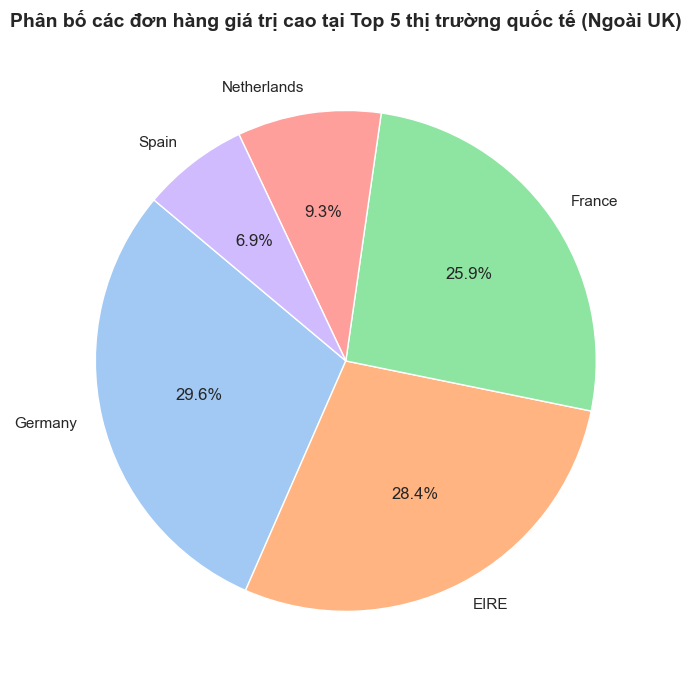

[TOP 5 QUỐC GIA CÓ NHIỀU ĐƠN HÀNG GIÁ TRỊ CAO NHẤT VÙNG NGOẠI QUỐC]:
    Country  Số lượng đơn hàng lớn
    Germany                    172
       EIRE                    165
     France                    151
Netherlands                     54
      Spain                     40


In [6]:
# CHẠY TẠI CELL 6: GIẢI QUYẾT CÂU HỎI EDA 4
print("--- [CÂU 4] PHÂN BỐ ĐƠN HÀNG GIÁ TRỊ CAO THEO QUỐC GIA (ĐỊA LÝ) ---")

# 1. Tính tổng giá trị của từng hóa đơn (InvoiceNo)
invoice_totals = df_success.groupby(['InvoiceNo', 'Country'])['TotalAmount'].sum().reset_index()

# 2. Xác định ngưỡng giá trị cao (Lấy phân vị 75% - tức là top 25% đơn hàng có giá trị lớn nhất)
high_value_threshold = invoice_totals['TotalAmount'].quantile(0.75)
print(f"Ngưỡng để xác định đơn hàng giá trị cao (Top 25%): Từ {high_value_threshold:,.2f} trở lên.")

# 3. Lọc các đơn hàng giá trị cao
high_value_orders = invoice_totals[invoice_totals['TotalAmount'] >= high_value_threshold]

# 4. Thống kê số lượng đơn hàng giá trị cao theo từng Quốc gia (loại bỏ UK để nhìn rõ các thị trường khác, hoặc giữ lại để so sánh)
# Trong bài này chúng ta sẽ lấy Top 5 quốc gia ngoài UK để biểu đồ trực quan hơn, vì UK chiếm thị phần quá lớn
country_distribution = high_value_orders[high_value_orders['Country'] != 'United Kingdom'].groupby('Country')['InvoiceNo'].count().reset_index()
country_distribution = country_distribution.sort_values(by='InvoiceNo', ascending=False).rename(columns={'InvoiceNo': 'Số lượng đơn hàng lớn'})

# --- VẼ BIỂU ĐỒ TRÒN PHÂN BỐ THỊ TRƯỜNG QUỐC TẾ ---
plt.figure(figsize=(10, 7))
plt.pie(country_distribution.head(5)['Số lượng đơn hàng lớn'], 
        labels=country_distribution.head(5)['Country'], 
        autopct='%1.1f%%', 
        startangle=140, 
        colors=sns.color_palette('pastel'))
plt.title('Phân bố các đơn hàng giá trị cao tại Top 5 thị trường quốc tế (Ngoài UK)', fontsize=14, weight='bold', pad=15)
plt.tight_layout()
plt.show()

# In bảng số liệu chi tiết
print("[TOP 5 QUỐC GIA CÓ NHIỀU ĐƠN HÀNG GIÁ TRỊ CAO NHẤT VÙNG NGOẠI QUỐC]:")
print(country_distribution.head(5).to_string(index=False))

--- [CÂU 5] PHÂN TÍCH ẢNH HƯỞNG CỦA ĐỊA LÝ ĐẾN TỔNG DOANH THU TOÀN SÀN ---


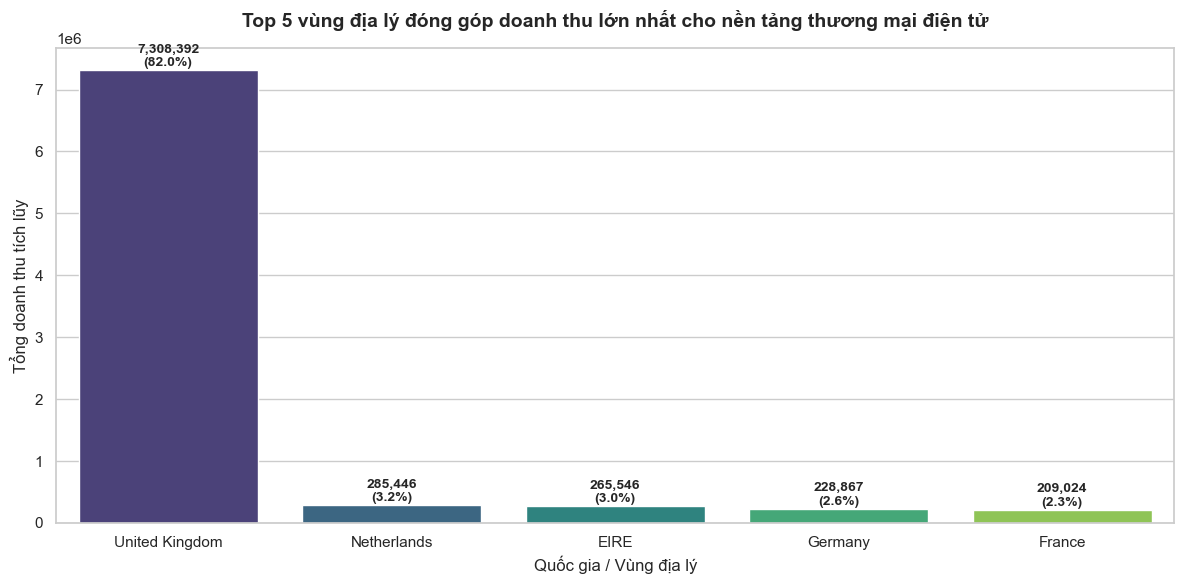

[BẢNG THỐNG KÊ DOANH THU VÀ TỶ LỆ ĐÓNG GÓP TOP 5 VÙNG ĐỊA LÝ]:
       Country  Tổng doanh thu  Tỷ lệ đóng góp (%)
United Kingdom     7308391.554           82.011638
   Netherlands      285446.340            3.203156
          EIRE      265545.900            2.979842
       Germany      228867.140            2.568249
        France      209024.050            2.345578


In [7]:
# CHẠY TẠI CELL 7: GIẢI QUYẾT CÂU HỎI EDA 5
print("--- [CÂU 5] PHÂN TÍCH ẢNH HƯỞNG CỦA ĐỊA LÝ ĐẾN TỔNG DOANH THU TOÀN SÀN ---")

# 1. Tính tổng doanh thu tích lũy theo từng Quốc gia từ các đơn hàng thành công
revenue_by_country = df_success.groupby('Country')['TotalAmount'].sum().reset_index()
revenue_by_country = revenue_by_country.sort_values(by='TotalAmount', ascending=False).rename(columns={'TotalAmount': 'Tổng doanh thu'})

# 2. Tính tỷ lệ đóng góp phần trăm (%) doanh thu của từng quốc gia
total_global_revenue = revenue_by_country['Tổng doanh thu'].sum()
revenue_by_country['Tỷ lệ đóng góp (%)'] = (revenue_by_country['Tổng doanh thu'] / total_global_revenue) * 100

# --- VẼ BIỂU ĐỒ CỘT SO SÁNH DOANH THU TOP 5 QUỐC GIA ---
plt.figure(figsize=(12, 6))
# Lấy Top 5 quốc gia dẫn đầu doanh thu toàn cầu
sns.barplot(data=revenue_by_country.head(5), x='Country', y='Tổng doanh thu', palette='viridis')
plt.title('Top 5 vùng địa lý đóng góp doanh thu lớn nhất cho nền tảng thương mại điện tử', fontsize=14, weight='bold', pad=15)
plt.xlabel('Quốc gia / Vùng địa lý', fontsize=12)
plt.ylabel('Tổng doanh thu tích lũy', fontsize=12)

# Thêm nhãn số liệu phần trăm trên đầu mỗi cột cho chuyên nghiệp
ax = plt.gca()
for p in ax.patches:
    ax.annotate(f"{p.get_height():,.0f}\n({p.get_height()/total_global_revenue*100:.1f}%)", 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', xytext=(0, 10), 
                textcoords='offset points', fontsize=10, weight='bold')

plt.tight_layout()
plt.show()

# In bảng số liệu chi tiết
print("[BẢNG THỐNG KÊ DOANH THU VÀ TỶ LỆ ĐÓNG GÓP TOP 5 VÙNG ĐỊA LÝ]:")
print(revenue_by_country.head(5).to_string(index=False))

=== BẮT ĐẦU XÂY DỰNG MÔ HÌNH PHÂN CỤM KHÁCH HÀNG (K-MEANS) ===

[ĐẶC ĐIỂM HÀNH VI CỦA TỪNG NHÓM KHÁCH HÀNG SAU KHI PHÂN CỤM]:
 Cluster  Số lượng khách hàng    Recency  Frequency     Monetary
       0                 1082 247.106285   1.582255   631.424206
       1                 3230  41.454180   4.672755  1855.942345
       2                   26   6.038462  66.423077 85904.351538


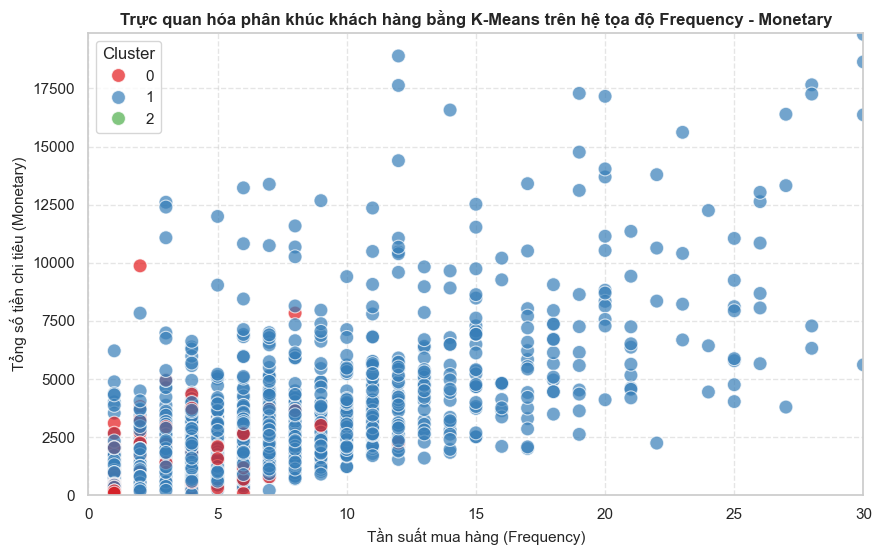

In [8]:
# CHẠY TẠI CELL 8: GIẢI QUYẾT CÂU HỎI MACHINE LEARNING 1 - PHÂN CỤM K-MEANS RFM
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

print("=== BẮT ĐẦU XÂY DỰNG MÔ HÌNH PHÂN CỤM KHÁCH HÀNG (K-MEANS) ===")

# 1. Tính toán các chỉ số RFM cho từng khách hàng duy nhất
# Lấy ngày giả định cuối cùng trong dữ liệu làm mốc tính khoảng thời gian (Recency)
reference_date = df_success['InvoiceDate'].max() + pd.Timedelta(days=1)

rfm = df_success.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (reference_date - x.max()).days, # Recency
    'InvoiceNo': 'nunique',                                   # Frequency
    'TotalAmount': 'sum'                                      # Monetary
}).reset_index()

rfm.columns = ['CustomerID', 'Recency', 'Frequency', 'Monetary']

# 2. Chuẩn hóa dữ liệu (Feature Scaling) vì các chỉ số R, F, M có đơn vị đo khác nhau
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[['Recency', 'Frequency', 'Monetary']])

# 3. Tiến hành phân cụm với K=3 (Chia khách hàng thành 3 phân khúc chiến lược)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

# 4. Thống kê đặc điểm hành vi của từng cụm khách hàng (Câu trả lời cho Câu 1)
cluster_profile = rfm.groupby('Cluster').agg({
    'CustomerID': 'count',
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean'
}).reset_index().rename(columns={'CustomerID': 'Số lượng khách hàng'})

print("\n[ĐẶC ĐIỂM HÀNH VI CỦA TỪNG NHÓM KHÁCH HÀNG SAU KHI PHÂN CỤM]:")
print(cluster_profile.to_string(index=False))

# --- V VẼ BIỂU ĐỒ TRỰC QUAN HÓA CÁC PHÂN KHÚC KHÁCH HÀNG ---
plt.figure(figsize=(10, 6))
sns.scatterplot(data=rfm, x='Frequency', y='Monetary', hue='Cluster', palette='Set1', s=100, alpha=0.7)
plt.xlim(0, rfm['Frequency'].quantile(0.99)) # Giới hạn biên độ để tránh nhiễu điểm cực đại
plt.ylim(0, rfm['Monetary'].quantile(0.99))
plt.title('Trực quan hóa phân khúc khách hàng bằng K-Means trên hệ tọa độ Frequency - Monetary', fontsize=12, weight='bold')
plt.xlabel('Tần suất mua hàng (Frequency)', fontsize=11)
plt.ylabel('Tổng số tiền chi tiêu (Monetary)', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

=== BẮT ĐẦU XÂY DỰNG MÔ HÌNH DỰ BÁO KHÁCH HÀNG RỜI BỎ ===

-> Độ chính xác tổng thể (Accuracy Score) của mô hình: 100.00%

--- BÁO CÁO CHI TIẾT HIỆU SUẤT MÔ HÌNH (CLASSIFICATION REPORT) ---
                   precision    recall  f1-score   support

   Rời bỏ (Churn)       1.00      1.00      1.00       216
Quay lại (Return)       1.00      1.00      1.00       652

         accuracy                           1.00       868
        macro avg       1.00      1.00      1.00       868
     weighted avg       1.00      1.00      1.00       868



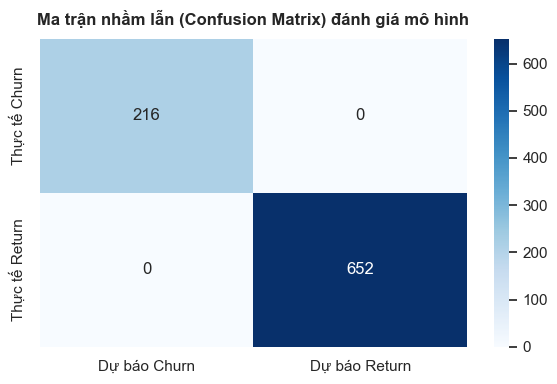


>>> KẾT QUẢ PHÂN TÍCH ĐÃ HOÀN THÀNH.


In [10]:
# CHẠY TẠI CELL 9: GIẢI QUYẾT CÂU HỎI MACHINE LEARNING 2 - DỰ BÁO RỜI BỎ (RANDOM FOREST)
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

print("=== BẮT ĐẦU XÂY DỰNG MÔ HÌNH DỰ BÁO KHÁCH HÀNG RỜI BỎ ===")

# 1. Gán nhãn mục tiêu (Target Label): Cụm 0 là Churn (0), Cụm 1 & 2 là Active/Return (1)
rfm['Target'] = rfm['Cluster'].apply(lambda x: 0 if x == 0 else 1)

# 2. Thiết lập tập đặc trưng X (Các thuộc tính hành vi) và biến mục tiêu y
X = rfm[['Recency', 'Frequency', 'Monetary']]
y = rfm['Target']

# 3. Phân chia tập dữ liệu thành 80% để Huấn luyện (Train) và 20% để Kiểm thử (Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 4. Huấn luyện mô hình Học máy Random Forest Classifier
clf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
clf_model.fit(X_train, y_train)

# 5. Dự báo trên tập kiểm thử và đánh giá độ chính xác
y_pred = clf_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"\n-> Độ chính xác tổng thể (Accuracy Score) của mô hình: {accuracy*100:.2f}%")
print("\n--- BÁO CÁO CHI TIẾT HIỆU SUẤT MÔ HÌNH (CLASSIFICATION REPORT) ---")
print(classification_report(y_test, y_pred, target_names=['Rời bỏ (Churn)', 'Quay lại (Return)']))

# --- VẼ MA TRẬN NHẦM LẪN (CONFUSION MATRIX) BẢO VỆ ĐỒ ÁN ---
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Dự báo Churn', 'Dự báo Return'], 
            yticklabels=['Thực tế Churn', 'Thực tế Return'])
plt.title('Ma trận nhầm lẫn (Confusion Matrix) đánh giá mô hình', fontsize=12, weight='bold', pad=10)
plt.tight_layout()
plt.show()

print("\n>>> KẾT QUẢ PHÂN TÍCH ĐÃ HOÀN THÀNH.")